In [ ]:
# EfficientNet-B0를 뇌종양 MRI 데이터로 Fine-tuning하는 학습 코드

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, Subset
import matplotlib.pyplot as plt
import numpy as np
import os
import time

In [ ]:
# GPU 사용 여부 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 디바이스: {device}")

사용 디바이스: cuda


In [ ]:
BASE_PATH  = "/content/drive/MyDrive/AI_Project/BrainScan_XAI/archive"
MODEL_PATH = "/content/drive/MyDrive/AI_Project/BrainScan_XAI/models"
TRAIN_PATH = os.path.join(BASE_PATH, "Training")
TEST_PATH  = os.path.join(BASE_PATH, "Testing")
os.makedirs(MODEL_PATH, exist_ok=True)

BATCH_SIZE  = 32
IMG_SIZE    = 224
VAL_RATIO   = 0.2
NUM_EPOCHS  = 20       # 15 → 20
LR          = 0.0005   # 0.001 → 0.0005
NUM_CLASSES = 4

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Train/Val 분할 인덱스 추출
full_train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=train_transform)
val_size   = int(len(full_train_dataset) * VAL_RATIO)
train_size = len(full_train_dataset) - val_size

train_indices, val_indices = random_split(
    range(len(full_train_dataset)), [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Train · Val 각각 다른 transform으로 독립 생성 (버그 수정)
train_dataset = Subset(
    datasets.ImageFolder(TRAIN_PATH, transform=train_transform),
    train_indices
)
val_dataset = Subset(
    datasets.ImageFolder(TRAIN_PATH, transform=val_test_transform),
    val_indices
)
test_dataset = datasets.ImageFolder(TEST_PATH, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

CLASSES = full_train_dataset.classes
print(f"Train: {train_size} / Val: {val_size} / Test: {len(test_dataset)}")
print(f"클래스: {CLASSES}")

Train: 4493 / Val: 1123 / Test: 1600
클래스: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
# 모델 정의

model = models.efficientnet_b3(weights='IMAGENET1K_V1')

in_features = model.classifier[1].in_features

# Dropout 추가로 과적합 방지
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, NUM_CLASSES)
)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# CosineAnnealingLR로 교체 (부드러운 lr 감소)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print(f"모델 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 144MB/s]


모델 파라미터 수: 10,702,380


In [ ]:
# 학습 루프
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        start = time.time()

        # ── Train ──
        model.train()
        train_loss, train_correct = 0.0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss    += loss.item() * images.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()

        # ── Validation ──
        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss    += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()

        t_loss = train_loss / train_size
        t_acc  = train_correct / train_size
        v_loss = val_loss / val_size
        v_acc  = val_correct / val_size
        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)
        scheduler.step()

        if v_acc > best_val_acc:
            best_val_acc = v_acc
            torch.save(model.state_dict(), os.path.join(MODEL_PATH, 'best_model.pth'))
            print(f"  → 모델 저장 (Val Acc: {v_acc:.4f})")

        elapsed = time.time() - start
        print(f"Epoch [{epoch+1:02d}/{num_epochs}] "
              f"Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | "
              f"Val Loss: {v_loss:.4f} Acc: {v_acc:.4f} | "
              f"시간: {elapsed:.1f}s")

    return history

history = train_model(model, train_loader, val_loader,
                      criterion, optimizer, scheduler, NUM_EPOCHS)

  → 모델 저장 (Val Acc: 0.9207)
Epoch [01/20] Train Loss: 0.3604 Acc: 0.8696 | Val Loss: 0.2118 Acc: 0.9207 | 시간: 2640.9s
  → 모델 저장 (Val Acc: 0.9617)
Epoch [02/20] Train Loss: 0.1610 Acc: 0.9437 | Val Loss: 0.0990 Acc: 0.9617 | 시간: 97.7s
  → 모델 저장 (Val Acc: 0.9813)
Epoch [03/20] Train Loss: 0.1129 Acc: 0.9608 | Val Loss: 0.0602 Acc: 0.9813 | 시간: 98.6s
Epoch [04/20] Train Loss: 0.0982 Acc: 0.9695 | Val Loss: 0.0786 Acc: 0.9760 | 시간: 103.2s
Epoch [05/20] Train Loss: 0.0640 Acc: 0.9786 | Val Loss: 0.0575 Acc: 0.9804 | 시간: 102.2s
  → 모델 저장 (Val Acc: 0.9866)
Epoch [06/20] Train Loss: 0.0556 Acc: 0.9811 | Val Loss: 0.0485 Acc: 0.9866 | 시간: 102.2s
Epoch [07/20] Train Loss: 0.0397 Acc: 0.9869 | Val Loss: 0.0378 Acc: 0.9866 | 시간: 102.8s
  → 모델 저장 (Val Acc: 0.9884)
Epoch [08/20] Train Loss: 0.0355 Acc: 0.9891 | Val Loss: 0.0406 Acc: 0.9884 | 시간: 99.3s
  → 모델 저장 (Val Acc: 0.9893)
Epoch [09/20] Train Loss: 0.0221 Acc: 0.9929 | Val Loss: 0.0330 Acc: 0.9893 | 시간: 101.0s
Epoch [10/20] Train Loss: 0.0199 

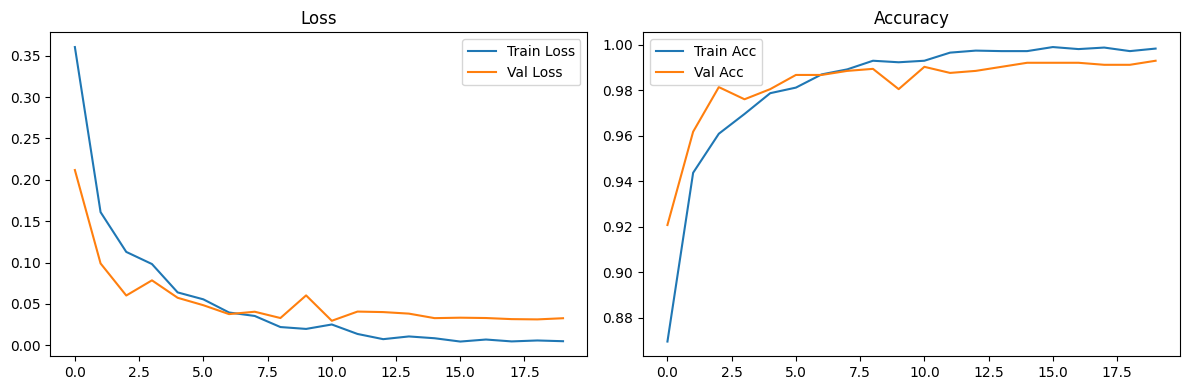

In [ ]:
# 학습 곡선 시각화

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'],   label='Val Loss')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train Acc')
axes[1].plot(history['val_acc'],   label='Val Acc')
axes[1].set_title('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(MODEL_PATH, 'training_curves.png'), dpi=150)
plt.show()

In [ ]:
# Test 평가

model.load_state_dict(torch.load(os.path.join(MODEL_PATH, 'best_model.pth')))
model.eval()

test_correct = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        test_correct += (outputs.argmax(1) == labels).sum().item()

test_acc = test_correct / len(test_dataset)
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")